<a href="https://colab.research.google.com/github/rkoo002-hub/DiabetesML/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
samples = df.shape[0]
features = df.shape[1] - 1
print("Samples: ", samples)
print("Features: ", features)


Samples:  100000
Features:  8


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
X = df.drop("diabetes", axis=1)
y = df["diabetes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train_shape", X_train.shape[0])
print("X_test_shape", X_test.shape[0])



X_train_shape 80000
X_test_shape 20000


In [ ]:
import pandas as pd
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
label_column = "diabetes"
X = df.drop(label_column, axis=1)
y = df[label_column]
print("Features: ")
print(X.columns.tolist())
print("Label: ")
print(label_column)

Features: 
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Label: 
diabetes


In [ ]:
import pandas as pd
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
print(df.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [ ]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [ ]:
import pandas as pd
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
print(df.describe())

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

In [ ]:
import pandas as pd
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
print(df.isnull().sum())
#since its 0 for all, I left out the rest of the code

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
#encode categorical columns
for col in df.select_dtypes(include='object'):
  df[col] = LabelEncoder().fit_transform(df[col])

#feature scaling
scalar = StandardScaler()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove("diabetes")
df[numeric_cols] = scalar.fit_transform(df[numeric_cols])

In [ ]:
print(df.head())


     gender       age  hypertension  heart_disease  smoking_history       bmi  \
0 -0.841047  1.692704     -0.284439       4.936379         0.963327 -0.321056   
1 -0.841047  0.538006     -0.284439      -0.202578        -1.153468 -0.000116   
2  1.187234 -0.616691     -0.284439      -0.202578         0.963327 -0.000116   
3 -0.841047 -0.261399     -0.284439      -0.202578        -0.624269 -0.583232   
4  1.187234  1.515058      3.515687       4.936379        -0.624269 -1.081970   

   HbA1c_level  blood_glucose_level  diabetes  
0     1.001706             0.047704         0  
1     1.001706            -1.426210         0  
2     0.161108             0.489878         0  
3    -0.492690             0.416183         0  
4    -0.679490             0.416183         0  


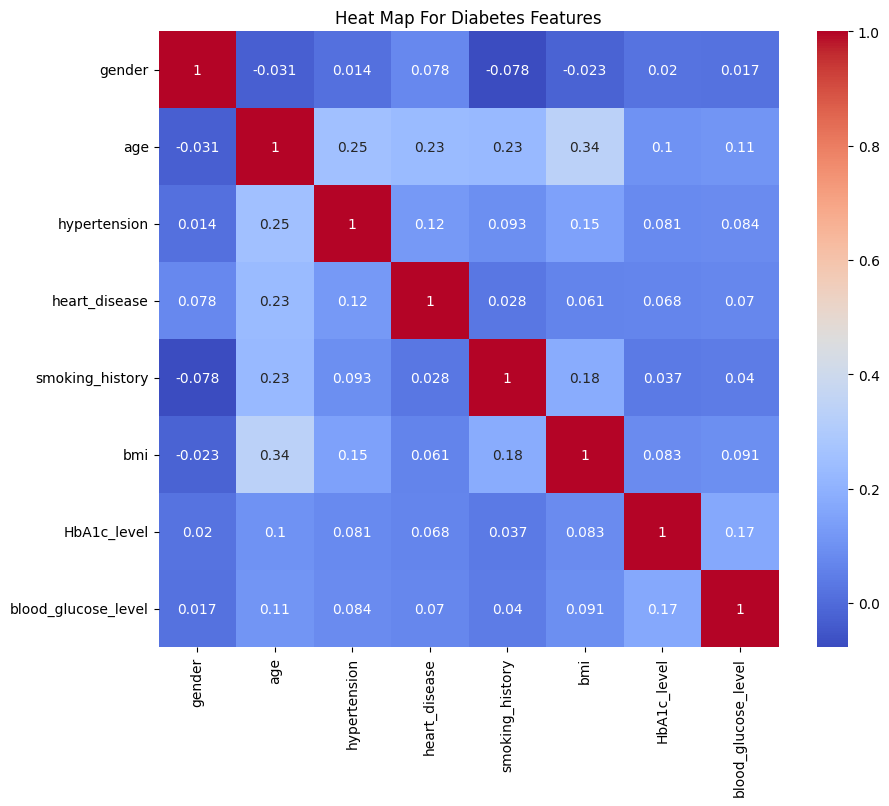

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.drop(columns=["diabetes"]).corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heat Map For Diabetes Features")
plt.show()
#since none of the features are strongly correlated with each other, we do not have to
#remove any

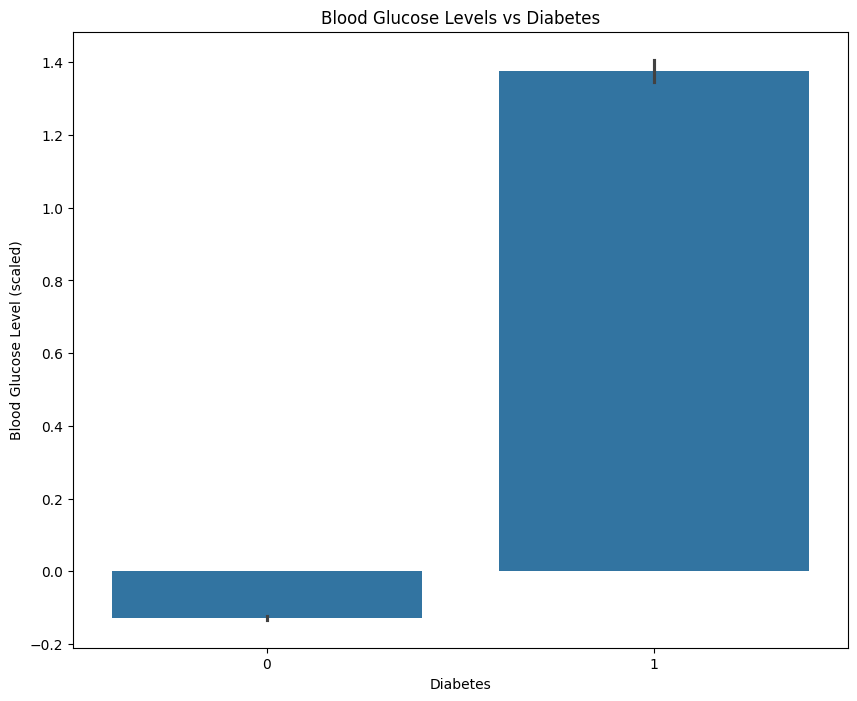

In [ ]:
#Bar Plot
#We see that people with diabetes have higher blood glucose levels comapred to those who do not have diabetes
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.barplot(x="diabetes", y="blood_glucose_level", data=df)
plt.title("Blood Glucose Levels vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Blood Glucose Level (scaled)")
plt.show()

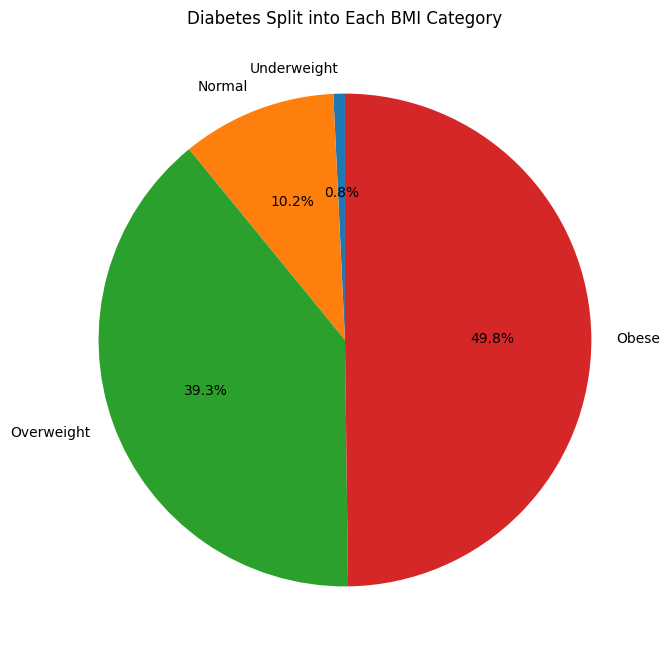

In [ ]:
#Pie plot
#this shows that the numebr of people that have higher BMI are more likely to have diabetes as we
#can see that majority of patients that have diabetes are either 'Overweight' or 'Obese'.
import pandas as pd
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")

bins = [0, 18.5, 25, 30, 100]
labels = ["Underweight", "Normal", "Overweight", "Obese"]
df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)
bmi_category_counts = df[df["diabetes"] == 1]["bmi_category"].value_counts().reindex(labels, fill_value=0)
plt.figure(figsize=(10, 8))
plt.pie(bmi_category_counts, labels=bmi_category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Diabetes Split into Each BMI Category")
plt.show()


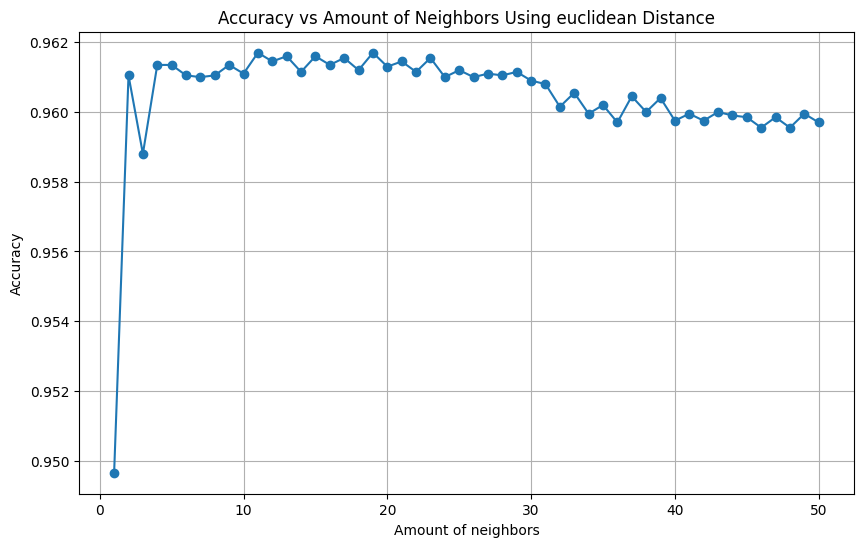

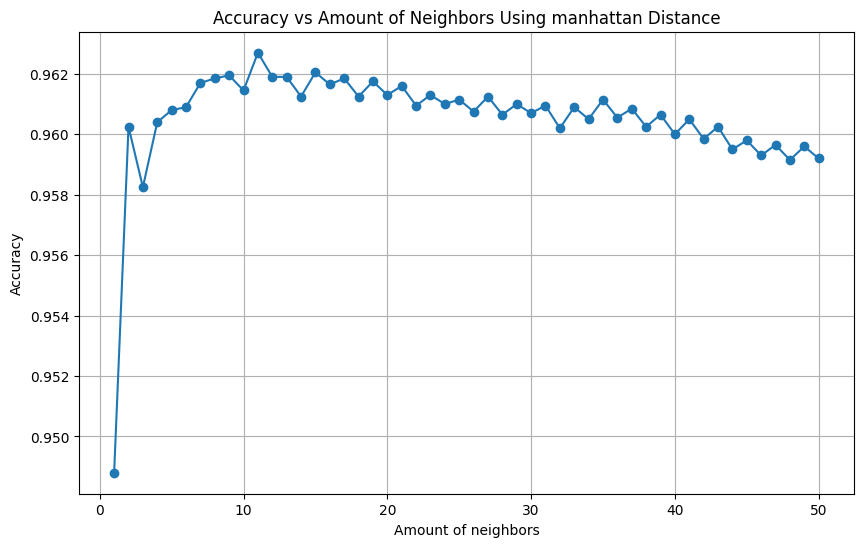

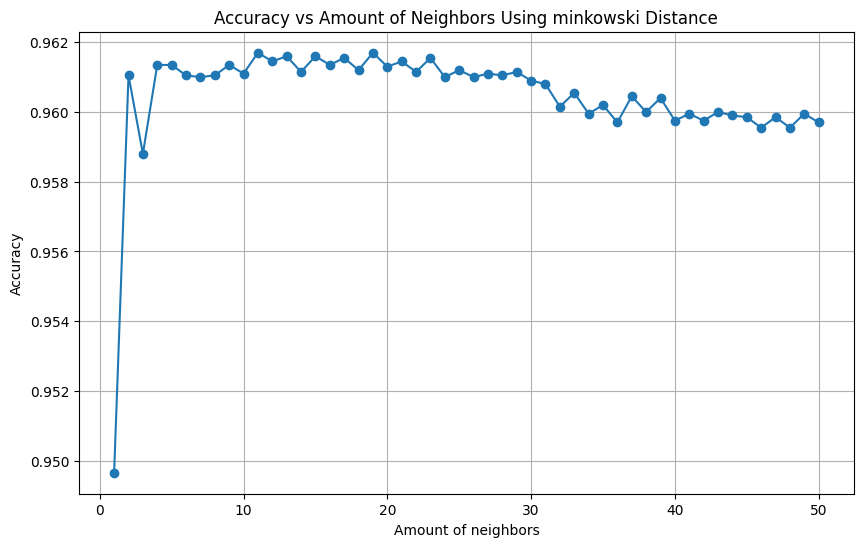

Best k Neighbor: 11
Best Distance Metric: manhattan
Best Accuracy: 0.9627
[[1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 [0.81818182 0.18181818]]
KNN Accuracy: 0.9627
KNN Precision: 0.9572243346007605
KNN Recall: 0.5895784543325527
KNN F1-score: 0.7297101449275363
Confusion Matrix:
 [[18247    45]
 [  701  1007]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.96      0.59      0.73      1708

    accuracy                           0.96     20000
   macro avg       0.96      0.79      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [ ]:
#KNN
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

for col in df.select_dtypes(include="object"):
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

dist_metrics = ["euclidean", "manhattan", "minkowski"]
best_accuracy = 0
best_k = None
best_metric = None


for metric in dist_metrics:
  accuracies = []
  for k in range(1, 51):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    if acc > best_accuracy:
      best_accuracy = acc
      best_k = k
      best_metric = metric

  plt.figure(figsize=(10, 6))
  plt.plot(range(1, 51), accuracies, marker="o")
  plt.xlabel("Amount of neighbors")
  plt.ylabel("Accuracy")
  plt.title(f"Accuracy vs Amount of Neighbors Using {metric} Distance")
  plt.grid(True)
  plt.show()

print("Best k Neighbor:", best_k)
print("Best Distance Metric:", best_metric)
print("Best Accuracy:", best_accuracy)

final_knn = KNeighborsClassifier(n_neighbors=best_k, metric = best_metric)
final_knn.fit(X_train, y_train)
y_pred_prob_knn = final_knn.predict_proba(X_test)
print(y_pred_prob_knn[:5])
final_y_pred = final_knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, final_y_pred))
print("KNN Precision:", precision_score(y_test, final_y_pred))
print("KNN Recall:", recall_score(y_test, final_y_pred))
print("KNN F1-score:", f1_score(y_test, final_y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_y_pred))
print(classification_report(y_test, final_y_pred))

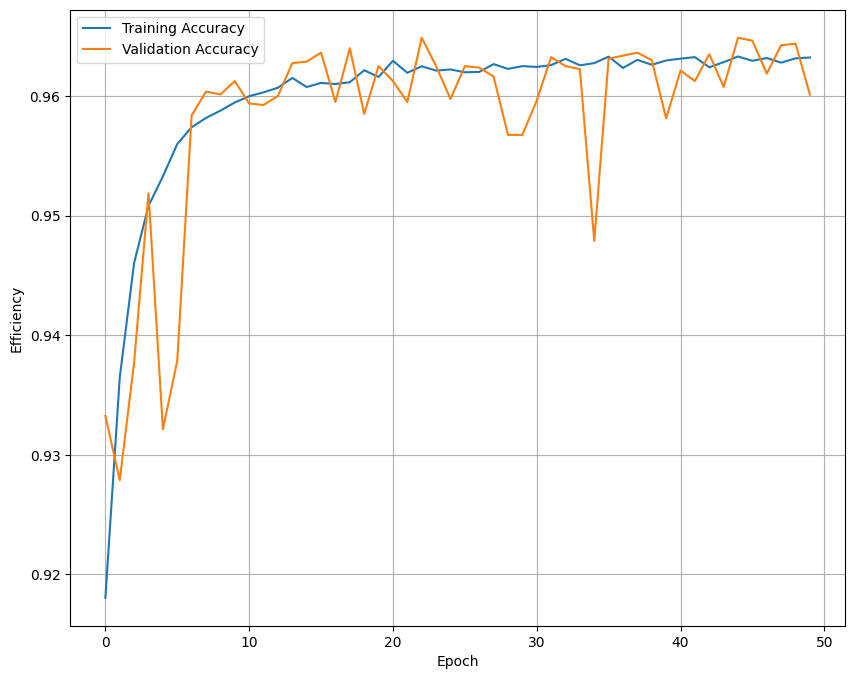

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[9.9845129e-01 1.5486549e-03]
 [9.9999863e-01 1.2517672e-06]
 [9.9823642e-01 1.7635932e-03]
 [9.9810368e-01 1.8962682e-03]
 [9.3531263e-01 6.4687379e-02]]
MLP Accuracy: 0.9611
MLP Precision: 0.9702458495304993
MLP Recall: 0.7772909517271471
MLP F1-score: 0.844211533344579
Confusion Matrix:
 [[18273    19]
 [  759   949]]


In [ ]:
#CNN


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


df = pd.read_csv("/content/diabetes_prediction_dataset.csv")


for col in df.select_dtypes(include="object"):
   df[col] = LabelEncoder().fit_transform(df[col])


X = df.drop("diabetes", axis=1).values
y = df["diabetes"].values
y_cat = to_categorical(y, 2)


X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)


mlp = Sequential([
   Input(shape=(X_train.shape[1],)),
   Dense(32, activation='relu'),
   Dense(16, activation='relu'),
   Dense(2, activation='softmax')
])


mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = mlp.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.1, verbose=0)


plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)
plt.show()


import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_pred_probs = mlp.predict(X_test)
print(y_pred_probs[:5])
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)


accuracy = accuracy_score(y_test_labels, y_pred_labels)
precision = precision_score(y_test_labels, y_pred_labels, average='macro')
recall = recall_score(y_test_labels, y_pred_labels, average='macro')
f1 = f1_score(y_test_labels, y_pred_labels, average='macro')
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)


print("CNN Accuracy:", accuracy)
print("CNN Precision:", precision)
print("CNN Recall:", recall)
print("CNN F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

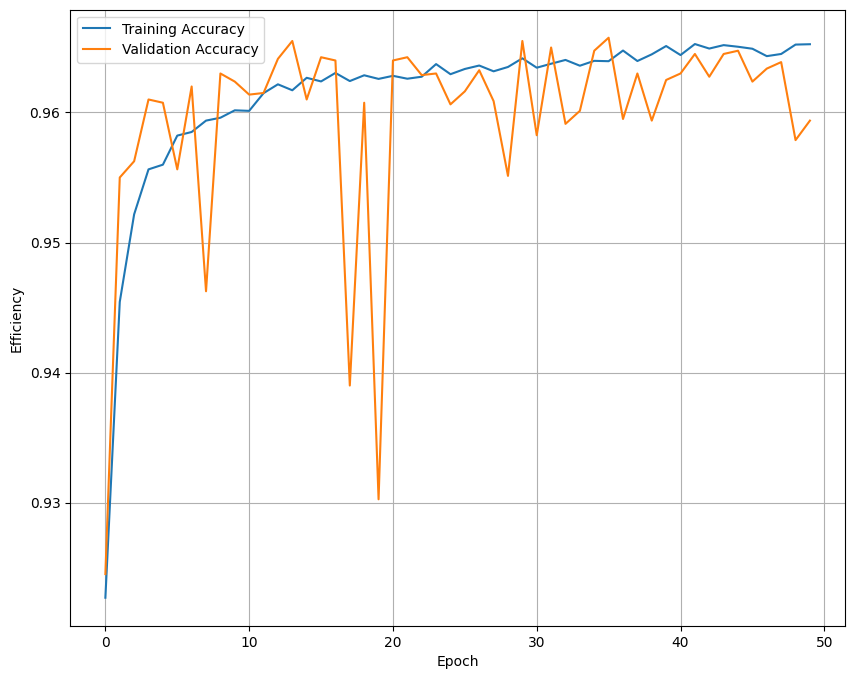

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[9.9912226e-01 8.7771495e-04]
 [9.9983978e-01 1.6021490e-04]
 [9.9949592e-01 5.0396158e-04]
 [9.9832803e-01 1.6719700e-03]
 [9.4168806e-01 5.8311980e-02]]
MLP Accuracy: 0.9592
MLP Precision: 0.977579489710457
MLP Recall: 0.7616549331659046
MLP F1-score: 0.8324077145686495
Confusion Matrix:
 [[18290     2]
 [  814   894]]


In [ ]:
#CNN
#in this we increase the size of the neural network

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


df = pd.read_csv("/content/diabetes_prediction_dataset.csv")


for col in df.select_dtypes(include="object"):
   df[col] = LabelEncoder().fit_transform(df[col])


X = df.drop("diabetes", axis=1).values
y = df["diabetes"].values
y_cat = to_categorical(y, 2)


X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)


mlp = Sequential([
   Input(shape=(X_train.shape[1],)),
   Dense(64, activation='relu'),
   Dense(32, activation='relu'),
   Dense(16, activation='relu'),
   Dense(2, activation='softmax')
])


mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = mlp.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.1, verbose=0)


plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)
plt.show()


import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_pred_probs = mlp.predict(X_test)
print(y_pred_probs[:5])
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)



accuracy = accuracy_score(y_test_labels, y_pred_labels)
precision = precision_score(y_test_labels, y_pred_labels, average='macro')
recall = recall_score(y_test_labels, y_pred_labels, average='macro')
f1 = f1_score(y_test_labels, y_pred_labels, average='macro')
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)


print("CNN Accuracy:", accuracy)
print("CNN Precision:", precision)
print("CNN Recall:", recall)
print("CNN F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

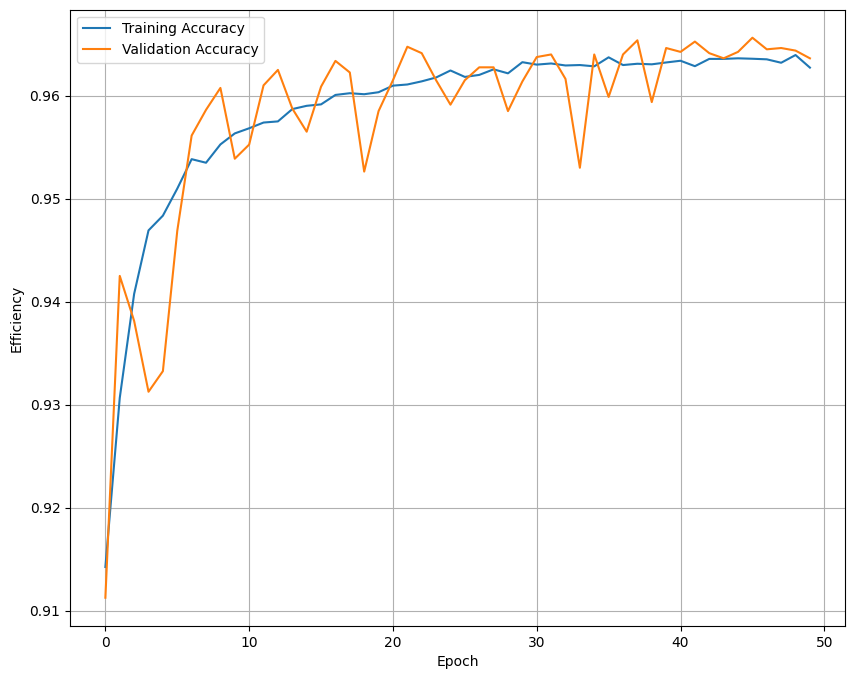

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[9.9954754e-01 4.5239044e-04]
 [9.9999958e-01 3.6261437e-07]
 [9.9270999e-01 7.2898637e-03]
 [9.9974799e-01 2.5210428e-04]
 [9.4775021e-01 5.2249804e-02]]
MLP Accuracy: 0.9639
MLP Precision: 0.9657141008571049
MLP Recall: 0.7976654797454359
MLP F1-score: 0.8596032122318349
Confusion Matrix:
 [[18258    34]
 [  688  1020]]


In [ ]:
#CNN
#In this we changed the batch size

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


df = pd.read_csv("/content/diabetes_prediction_dataset.csv")


for col in df.select_dtypes(include="object"):
   df[col] = LabelEncoder().fit_transform(df[col])


X = df.drop("diabetes", axis=1).values
y = df["diabetes"].values
y_cat = to_categorical(y, 2)


X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)


mlp = Sequential([
   Input(shape=(X_train.shape[1],)),
   Dense(32, activation='relu'),
   Dense(16, activation='relu'),
   Dense(2, activation='softmax')
])


mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = mlp.fit(X_train, y_train, epochs=50, batch_size=22, validation_split=0.1, verbose=0)


plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)
plt.show()


import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_pred_probs = mlp.predict(X_test)
print(y_pred_probs[:5])
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)



accuracy = accuracy_score(y_test_labels, y_pred_labels)
precision = precision_score(y_test_labels, y_pred_labels, average='macro')
recall = recall_score(y_test_labels, y_pred_labels, average='macro')
f1 = f1_score(y_test_labels, y_pred_labels, average='macro')
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)


print("CNN Accuracy:", accuracy)
print("CNN Precision:", precision)
print("CNN Recall:", recall)
print("CNN F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

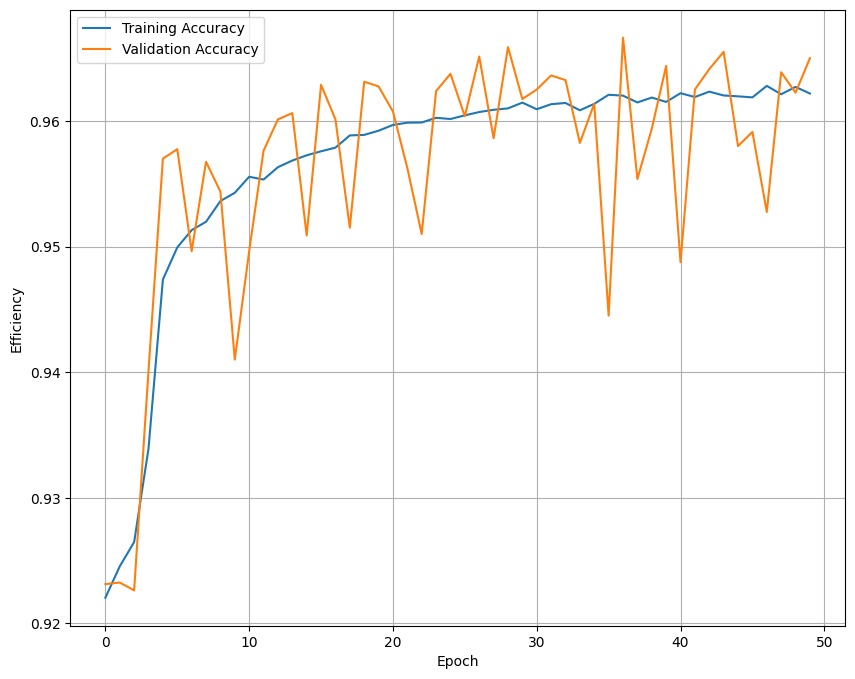

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[9.9751383e-01 2.4861144e-03]
 [9.9921924e-01 7.8079192e-04]
 [9.9937707e-01 6.2296039e-04]
 [9.9587440e-01 4.1255630e-03]
 [9.7138250e-01 2.8617591e-02]]
MLP Accuracy: 0.9651
MLP Precision: 0.9626638134879955
MLP Recall: 0.807345297799783
MLP F1-score: 0.8662404297231242
Confusion Matrix:
 [[18248    44]
 [  654  1054]]


In [ ]:
#CNN
#the activation function was changed to tanh


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


df = pd.read_csv("/content/diabetes_prediction_dataset.csv")


for col in df.select_dtypes(include="object"):
   df[col] = LabelEncoder().fit_transform(df[col])


X = df.drop("diabetes", axis=1).values
y = df["diabetes"].values
y_cat = to_categorical(y, 2)


X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)


mlp = Sequential([
   Input(shape=(X_train.shape[1],)),
   Dense(32, activation='tanh'),
   Dense(16, activation='tanh'),
   Dense(2, activation='softmax')
])


mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = mlp.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.1, verbose=0)


plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)
plt.show()


import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_pred_probs = mlp.predict(X_test)
print(y_pred_probs[:5])
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)



accuracy = accuracy_score(y_test_labels, y_pred_labels)
precision = precision_score(y_test_labels, y_pred_labels, average='macro')
recall = recall_score(y_test_labels, y_pred_labels, average='macro')
f1 = f1_score(y_test_labels, y_pred_labels, average='macro')
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)


print("CNN Accuracy:", accuracy)
print("CNN Precision:", precision)
print("CNN Recall:", recall)
print("CNN F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

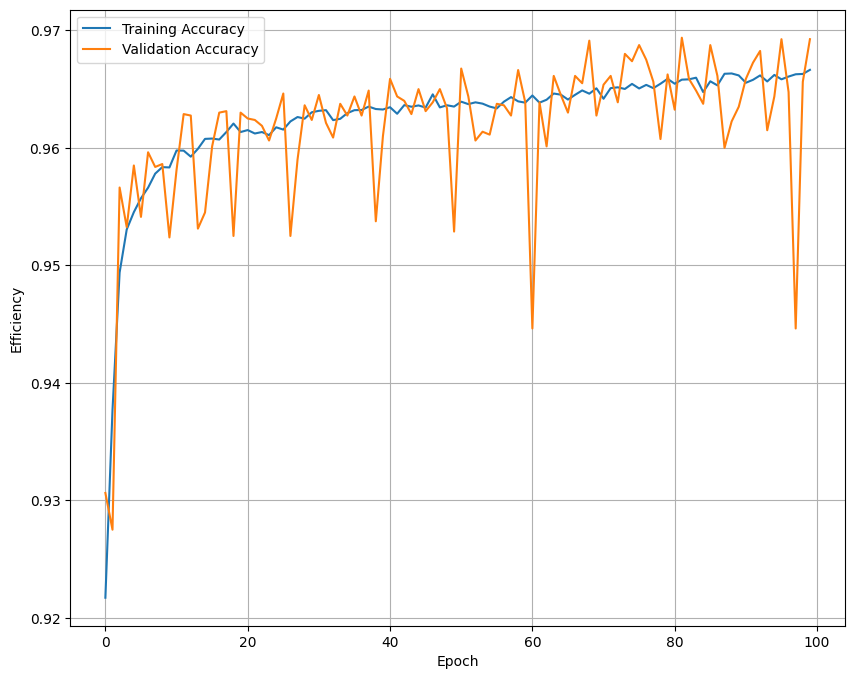

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[9.9822032e-01 1.7796719e-03]
 [9.9933606e-01 6.6389469e-04]
 [9.9999970e-01 2.9299392e-07]
 [9.9918360e-01 8.1641367e-04]
 [9.2753267e-01 7.2467290e-02]]
CNN Accuracy: 0.9701
CNN Precision: 0.9582506071147283
CNN Recall: 0.843254444809187
CNN F1-score: 0.8907783144617256
Confusion Matrix:
 [[18223    69]
 [  529  1179]]


In [ ]:
#CNN
#we changed the epoch from 50 to 100

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


df = pd.read_csv("/content/diabetes_prediction_dataset.csv")


for col in df.select_dtypes(include="object"):
   df[col] = LabelEncoder().fit_transform(df[col])


X = df.drop("diabetes", axis=1).values
y = df["diabetes"].values
y_cat = to_categorical(y, 2)


X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)


mlp = Sequential([
   Input(shape=(X_train.shape[1],)),
   Dense(32, activation='relu'),
   Dense(16, activation='relu'),
   Dense(2, activation='softmax')
])


mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = mlp.fit(X_train, y_train, epochs=100, batch_size=8, validation_split=0.1, verbose=0)


plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)
plt.show()


import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_pred_probs = mlp.predict(X_test)
print(y_pred_probs[:5])
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)


accuracy = accuracy_score(y_test_labels, y_pred_labels)
precision = precision_score(y_test_labels, y_pred_labels, average='macro')
recall = recall_score(y_test_labels, y_pred_labels, average='macro')
f1 = f1_score(y_test_labels, y_pred_labels, average='macro')
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)


print("CNN Accuracy:", accuracy)
print("CNN Precision:", precision)
print("CNN Recall:", recall)
print("CNN F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

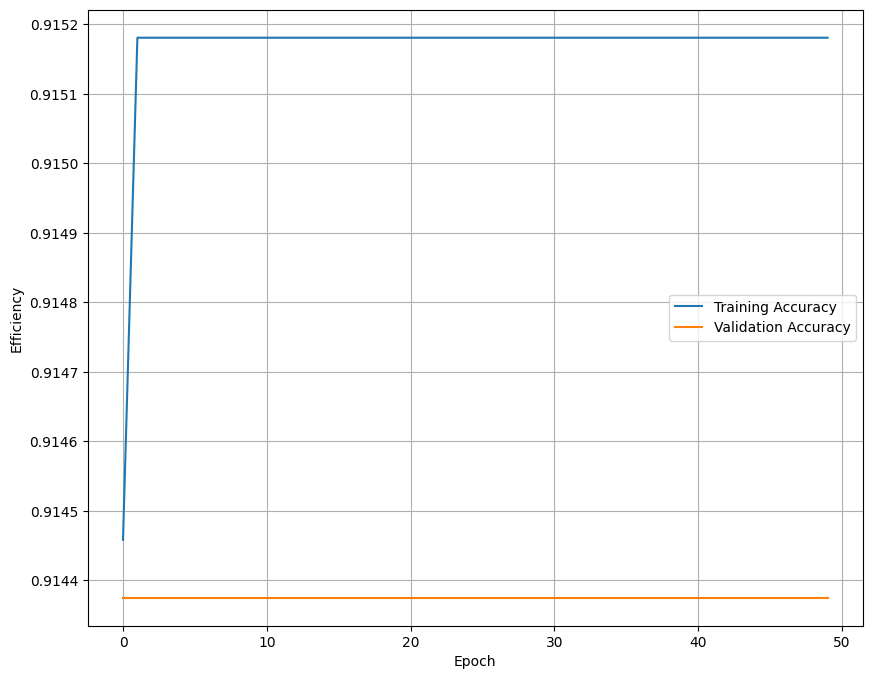

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[0.9200202  0.07997979]
 [0.9200202  0.07997979]
 [0.9200202  0.07997979]
 [0.9200202  0.07997979]
 [0.9200202  0.07997979]]
CNN Accuracy: 0.9146
CNN Precision: 0.4573
CNN Recall: 0.5
CNN F1-score: 0.4776976914237961
Confusion Matrix:
 [[18292     0]
 [ 1708     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#CNN
#for this the learning rate value was changed from 0.001 (adam) to 0.01

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


df = pd.read_csv("/content/diabetes_prediction_dataset.csv")


for col in df.select_dtypes(include="object"):
   df[col] = LabelEncoder().fit_transform(df[col])


X = df.drop("diabetes", axis=1).values
y = df["diabetes"].values
y_cat = to_categorical(y, 2)


X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)


mlp = Sequential([
   Input(shape=(X_train.shape[1],)),
   Dense(32, activation='relu'),
   Dense(16, activation='relu'),
   Dense(2, activation='softmax')
])


mlp.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
history = mlp.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.1, verbose=0)


plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)
plt.show()


import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_pred_probs = mlp.predict(X_test)
print(y_pred_probs[:5])
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)


accuracy = accuracy_score(y_test_labels, y_pred_labels)
precision = precision_score(y_test_labels, y_pred_labels, average='macro')
recall = recall_score(y_test_labels, y_pred_labels, average='macro')
f1 = f1_score(y_test_labels, y_pred_labels, average='macro')
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)


print("CNN Accuracy:", accuracy)
print("CNN Precision:", precision)
print("CNN Recall:", recall)
print("CNN F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)